In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/panther_merged.csv")
df.shape

C:\Users\HP\AppData\Local\Temp\ipykernel_7488\1597317179.py:6: DtypeWarning: Columns (0: chilledwater, 1: water, 2: irrigation, 3: gas, 4: eui, 5: leed_level) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/panther_merged.csv")


(1842120, 42)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1842120 entries, 0 to 1842119
Data columns (total 42 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   timestamp              str    
 1   building_id            str    
 2   meter_reading          float64
 3   site_id                str    
 4   airTemperature         float64
 5   cloudCoverage          float64
 6   dewTemperature         float64
 7   precipDepth1HR         float64
 8   precipDepth6HR         float64
 9   seaLvlPressure         float64
 10  windDirection          float64
 11  windSpeed              float64
 12  building_id_kaggle     float64
 13  site_id_kaggle         float64
 14  primaryspaceusage      str    
 15  sub_primaryspaceusage  str    
 16  sqm                    float64
 17  sqft                   float64
 18  lat                    float64
 19  lng                    float64
 20  timezone               str    
 21  electricity            str    
 22  hotwater               float6

In [18]:
missing_summary = df.isna().mean().sort_values(ascending=False) * 100
missing_summary

occupants                100.000000
numberoffloors           100.000000
rating                   100.000000
source_eui               100.000000
site_eui                 100.000000
subindustry              100.000000
date_opened              100.000000
energystarscore          100.000000
steam                    100.000000
hotwater                 100.000000
heatingtype              100.000000
solar                    100.000000
industry                 100.000000
precipDepth6HR            96.317829
leed_level                87.619048
irrigation                83.809524
chilledwater              76.190476
gas                       73.333333
cloudCoverage             42.989056
water                     25.714286
meter_reading             19.812390
windDirection              2.844277
seaLvlPressure             1.841085
precipDepth1HR             0.051300
airTemperature             0.017100
dewTemperature             0.017100
site_id                    0.000000
building_id                0

In [19]:
cols_to_drop = ['occupants', 'numberoffloors', 'rating', 'source_eui', 'site_eui',
                 'subindustry', 'date_opened', 'energystarscore', 'steam', 'hotwater',
                 'heatingtype', 'solar', 'industry', 'precipDepth6HR', 'leed_level',
                 'irrigation', 'chilledwater', 'gas', 'eui']

df = df.drop(columns=cols_to_drop)
df.shape

(1842120, 23)

In [20]:
raw_check = pd.read_csv("../data/processed/panther_merged.csv", usecols=['eui'])
raw_check['eui'].unique()[:10]

IndexError: list index out of range

In [ ]:
raw_check = pd.read_csv("../data/processed/panther_merged.csv", usecols=['eui'], dtype=str)
raw_check['eui'].unique()[:10]

In [ ]:
eui_col = pd.read_csv("../data/processed/panther_merged.csv", usecols=['eui'], dtype=str)
df['eui'] = pd.to_numeric(eui_col['eui'], errors='coerce')
df['eui'].isna().mean()

In [21]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp'].dtype

dtype('<M8[us]')

In [22]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df[['timestamp', 'hour', 'day_of_week', 'month']].head()

,timestamp,hour,day_of_week,month
0,2016-01-01 00:00:00,0,4,1
1,2016-01-01 01:00:00,1,4,1
2,2016-01-01 02:00:00,2,4,1
3,2016-01-01 03:00:00,3,4,1
4,2016-01-01 04:00:00,4,4,1


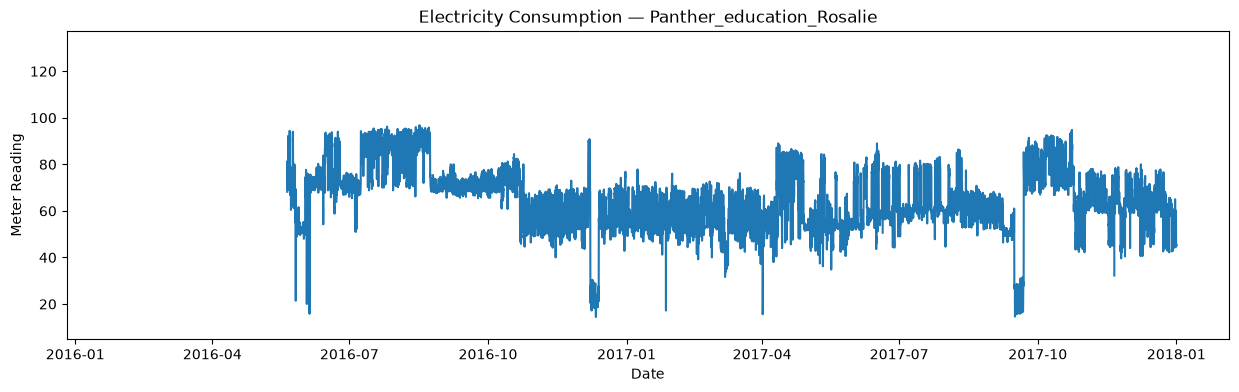

In [23]:
building_sample = df[df['building_id'] == 'Panther_education_Rosalie'].sort_values('timestamp')

plt.figure(figsize=(15, 4))
plt.plot(building_sample['timestamp'], building_sample['meter_reading'])
plt.title('Electricity Consumption — Panther_education_Rosalie')
plt.xlabel('Date')
plt.ylabel('Meter Reading')
plt.show()

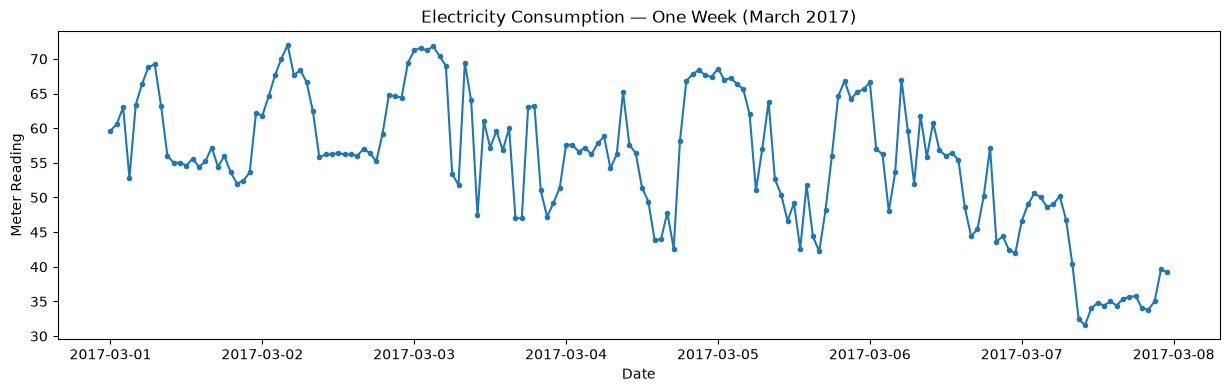

In [24]:
one_week = building_sample[(building_sample['timestamp'] >= '2017-03-01') & 
                             (building_sample['timestamp'] < '2017-03-08')]

plt.figure(figsize=(15, 4))
plt.plot(one_week['timestamp'], one_week['meter_reading'], marker='o', markersize=3)
plt.title('Electricity Consumption — One Week (March 2017)')
plt.xlabel('Date')
plt.ylabel('Meter Reading')
plt.show()

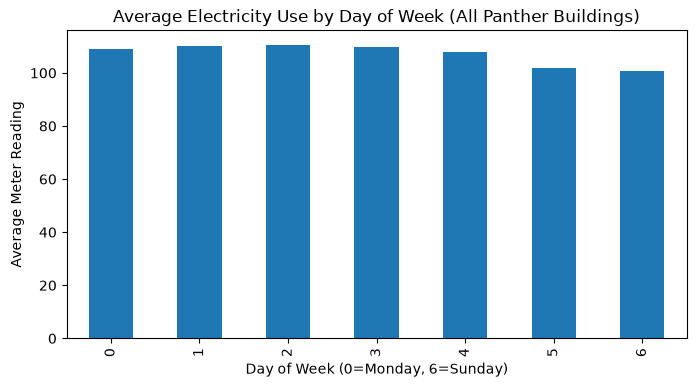

In [25]:
hourly_avg_by_dow = df.groupby('day_of_week')['meter_reading'].mean()

plt.figure(figsize=(8, 4))
hourly_avg_by_dow.plot(kind='bar')
plt.title('Average Electricity Use by Day of Week (All Panther Buildings)')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Meter Reading')
plt.show()

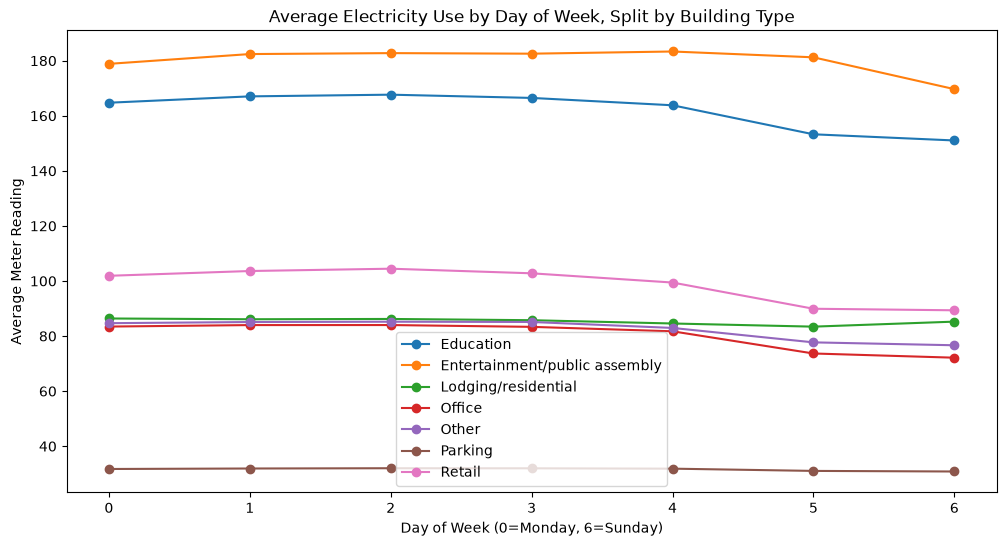

In [26]:
dow_by_type = df.groupby(['primaryspaceusage', 'day_of_week'])['meter_reading'].mean().unstack()

plt.figure(figsize=(12, 6))
for usage_type in dow_by_type.index:
    plt.plot(dow_by_type.columns, dow_by_type.loc[usage_type], marker='o', label=usage_type)

plt.title('Average Electricity Use by Day of Week, Split by Building Type')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Meter Reading')
plt.legend()
plt.show()

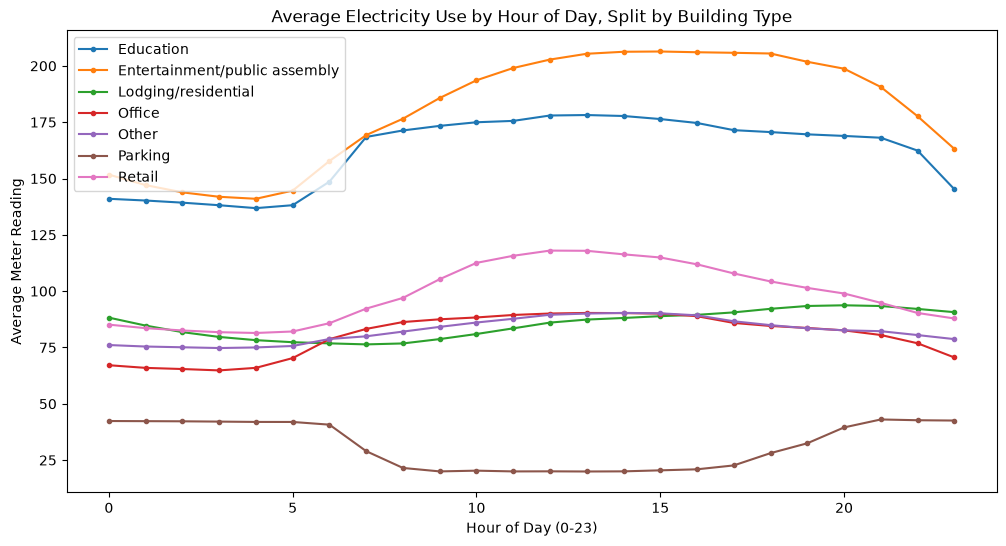

In [27]:
hour_by_type = df.groupby(['primaryspaceusage', 'hour'])['meter_reading'].mean().unstack(level=0)

plt.figure(figsize=(12, 6))
for usage_type in hour_by_type.columns:
    plt.plot(hour_by_type.index, hour_by_type[usage_type], marker='o', markersize=3, label=usage_type)

plt.title('Average Electricity Use by Hour of Day, Split by Building Type')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Meter Reading')
plt.legend()
plt.show()

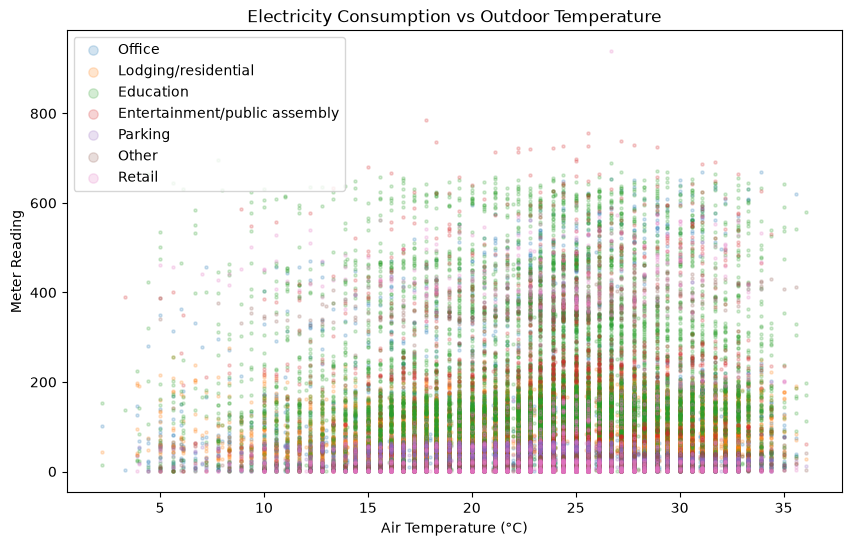

In [28]:
plt.figure(figsize=(10, 6))
sample = df.sample(50000, random_state=42)  

for usage_type in sample['primaryspaceusage'].unique():
    subset = sample[sample['primaryspaceusage'] == usage_type]
    plt.scatter(subset['airTemperature'], subset['meter_reading'], alpha=0.2, s=5, label=usage_type)

plt.title('Electricity Consumption vs Outdoor Temperature')
plt.xlabel('Air Temperature (°C)')
plt.ylabel('Meter Reading')
plt.legend(markerscale=3)
plt.show()

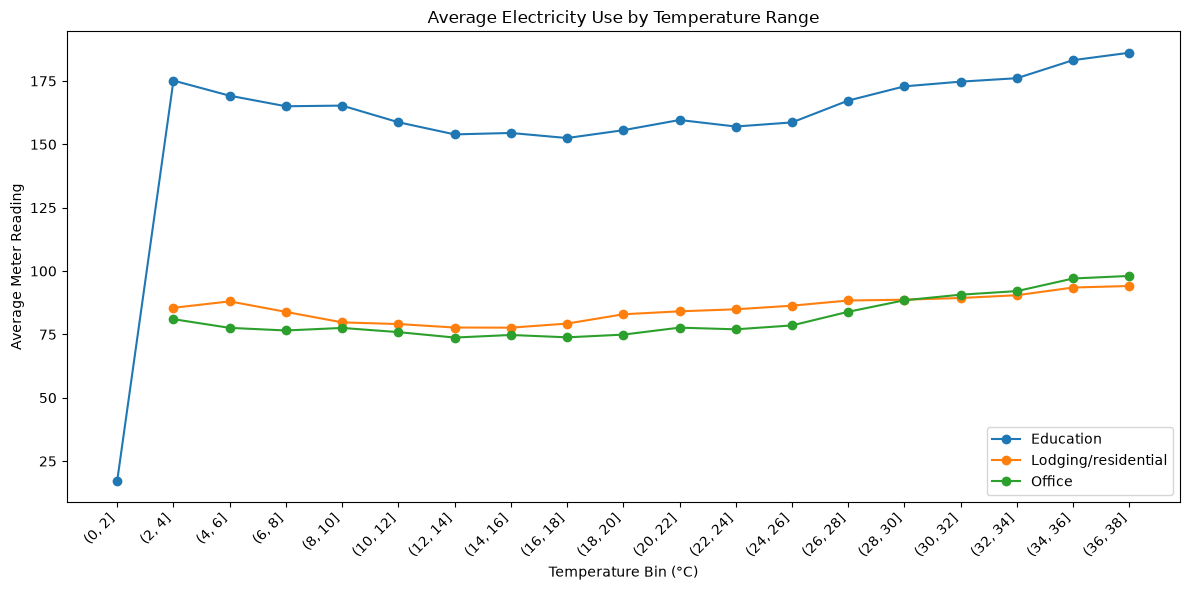

In [29]:
df['temp_bin'] = pd.cut(df['airTemperature'], bins=range(-10, 41, 2))

temp_pattern = df[df['primaryspaceusage'].isin(['Office', 'Education', 'Lodging/residential'])]
temp_pattern = temp_pattern.groupby(['primaryspaceusage', 'temp_bin'])['meter_reading'].mean().unstack(level=0)

plt.figure(figsize=(12, 6))
for usage_type in temp_pattern.columns:
    plt.plot(range(len(temp_pattern.index)), temp_pattern[usage_type], marker='o', label=usage_type)

plt.xticks(range(len(temp_pattern.index)), [str(i) for i in temp_pattern.index], rotation=45, ha='right')
plt.title('Average Electricity Use by Temperature Range')
plt.xlabel('Temperature Bin (°C)')
plt.ylabel('Average Meter Reading')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
df[df['temp_bin'] == pd.Interval(0, 2)]['primaryspaceusage'].value_counts()

primaryspaceusage
Education                        60
Lodging/residential              54
Office                           48
Parking                          16
Retail                           12
Entertainment/public assembly    10
Other                            10
Name: count, dtype: int64